In [1]:
import pyrpl
from pyrpl import Pyrpl
from datetime import datetime
from time import sleep
import time
import numpy as np
import matplotlib.pyplot as plt
from finesse.analysis.actions import Xaxis
import types
import matplotlib.animation as animation
import matplotlib
import scipy

from calibration.calibration import Calibrator

#Put in each relevant cell to allow for interactive plot rendering & animations
%matplotlib widget

plt.rcParams['text.usetex'] = True
plt.rcParams['savefig.dpi'] = 50
plt.rcParams['figure.constrained_layout.use'] = True



CONNECT_THROUGH_TUNNEL = True

# if(CONNECT_THROUGH_TUNNEL == True):
#     #ssh_tunnel = 'ssh -L 2222:localhost:2222 q-ifo@raspberrypi -t ssh -L 2222:localhost:2222 root@192.168.0.157'
#     #subprocess.run()
#     HOSTNAME = "pitaya-remote-proxy"

# else:
#     HOSTNAME = "192.168.0.157"

HOSTNAME= 'qifo-pitaya-1.local'#'192.168.0.157'
PASSWORD = "L!g0bears"

p = Pyrpl(config='', hostname=HOSTNAME, password=PASSWORD, gui=False)
rp = p.rp


INFO:pyrpl.redpitaya:Correct FPGA image detected, skipping reload
INFO:pyrpl.redpitaya:Successfully connected to Redpitaya with hostname qifo-pitaya-1.local.


In [2]:
c = 299792458
red_wavelength = 1064e-9
red_frequency = c / red_wavelength
green_wavelength = 532e-9
green_frequency = c / green_wavelength

n_crystal_red = 1.8302 #index of KTP crystal at 1064 nm
n_crystal_green = 1.8894 #index of KTP crystal at 532 nm



In [3]:
#Mostly relevant for faking refl_pd signal, besides modulation_freq which is used for demodulating the real signal
tunable_fc_params = dict(
    modulation_freq = 30e6,
    laser_power = 1, #532 nm laser power in watts
    L0 = np.ceil(20e-2 / red_wavelength) * red_wavelength,
    L = 0,
    t1 = 0.1,
    t2 = 0.001,
    sideband_depth = 1.08
)

params = types.SimpleNamespace(tunable_fc_params)
params.L = params.L0

EOM_V_pi = 6.2 #How many volts induces a pi phase shift from the EOM


In [ ]:
iq = rp.iq0
asg = rp.asg0
piezo_asg = rp.asg1
scope = rp.scope
control_pid = rp.pid0 

ports = types.SimpleNamespace(
    piezo = 'out1',
    refl_pd = 'in1',
    trans_pd = 'in2',
    local_oscillator = 'out2'
)

calibrator = Calibrator(config_file = "calibration/pitaya2_calibration.json")


In [ ]:
def lorentzian(x, A, B, g, x0):
    return (A / ((x-x0)**2 + g**2)) + B

def lorentzian_derivative(x, A, B, g, x0): #For lorentzian A / ((x-x0)^2 + g^2)
    return -2 * A * (x - x0) / (((x-x0)**2 + g**2)**2) + B


def cavity_transfer_function(omega, cavity_length):
    t1 = params.t1
    t2 = params.t2
    r1 = np.sqrt(1 - t1**2)
    r2 = np.sqrt(1 - t2**2)
    alpha = omega * cavity_length / c

    numerator = -r1 + (r1**2 + t1**2)*r2*np.exp(2j * alpha)
    denominator = 1 - r1 * r2 * np.exp(2j * alpha)
    return numerator / denominator 

def reflected_field(t, E0, L, omega, omega_m, beta):
    carrier_field = E0 * cavity_transfer_function(omega, L) * np.exp(1j * omega * t)

    sideband_field = (beta/2) * E0 * (cavity_transfer_function(omega+omega_m, L) * np.exp(1j * (omega + omega_m) * t) - cavity_transfer_function(omega-omega_m, L) * np.exp(1j * (omega - omega_m) * t))

    return carrier_field + sideband_field


def reflected_power(t, P0, cavity_length, f, sideband_f, beta):
    return np.abs(reflected_field(t, np.sqrt(P0), cavity_length, 2*np.pi*f, 2*np.pi*sideband_f, beta))**2


waveform_x = np.linspace(0, 1 / params.modulation_freq, num=16384)

waveform_y = 0.25 * reflected_power(waveform_x, params.laser_power, params.L, red_frequency, params.modulation_freq, params.sideband_depth)

In [ ]:
def set_iq(iq_module=iq, frequency:float=params.modulation_freq, bandwidth:list=[0,0], acbandwidth:float=0, phase:float=0, amplitude:float=1.0,
                  gain:float=0, input:str='off', LO_output:str='off', output_signal:str='quadrature', quadrature_factor:float=1):
    iq_module.setup(frequency=frequency, bandwidth = bandwidth, acbandwidth = acbandwidth, gain = gain, phase = phase, amplitude = amplitude, input = input,
                output_direct = LO_output, output_signal = output_signal, quadrature_factor = quadrature_factor)

def set_demodulator(frequency:float=params.modulation_freq, bandwidth:list=[10e3,20e3], acbandwidth:float=50000, phase:float=0, amplitude:float=0.98,
                  gain:float=0, input:str=ports.refl_pd, LO_output:str=ports.local_oscillator, output_signal:str='quadrature', quadrature_factor:float=1):
    set_demodulator(iq_module=iq, frequency=frequency, bandwidth = bandwidth, acbandwidth = acbandwidth, gain = gain, phase = phase, amplitude = amplitude, input = input,
            output_direct = LO_output, output_signal = output_signal, quadrature_factor = quadrature_factor)
    

def set_piezo_asg(output: str = ports.piezo, waveform:str = 'dc', frequency:float=1e0, amplitude:float = 1, offset:float = 0):
    piezo_asg.setup(waveform=waveform, output_direct=output, offset=offset, amplitude=amplitude, frequency=frequency, trigger_source='immediately')


def start_piezo_scan(output: str = ports.piezo, frequency: float = 1e0, amplitude: float = 0.5, offset:float = 0.5):
    set_piezo_asg(waveform = 'ramp', output=output, frequency=frequency, amplitude=amplitude, offset=offset)


def take_scan_trace(decimation: int = 256, input1:str=ports.piezo, input2:str=iq.name) -> list:
    # Scope samples at rate of 125 MHz, aka 1 sample per 1 / (125*10^6) = 8 * 10^-9 seconds
    # With decimation, it fills one data point per {decimation} samples, and the scope trace holds 2^14 samples
    # Thus scope traces / second = (trace / data point) * (1 data point / {decimation} samples) * (1 sample / 8*10^-9 seconds)
    # So the period of one scope trace is 8 * 10^-9 * 2^14 * {decimation}
    
    scope.decimation = decimation

    scope.input1 = input1
    scope.input2 = input2

    scope.threshold = piezo_asg.offset #+ piezo_asg.amplitude / 2 #Trigger on rising edge of piezo ramp
    scope.hysteresis = 0.01

    scope.trigger_source = 'ch1_positive_edge'
    scope.trigger_delay = 0

    return scope.single()

def take_immediate_scope_trace(decimation: int = 256, input1:str=ports.piezo, input2:str=iq.name) -> list:
    scope.decimation = decimation

    scope.input1 = input1
    scope.input2 = input2

    scope.threshold = 0
    scope.hysteresis = 0.01

    scope.trigger_source = 'immediately'
    scope.trigger_delay = 0

    return scope.single()

    
def set_pid(ival: float = 0, integrator: float = 1e3, proportional: float = 0, input:str=iq.name, output_direct:str=ports.piezo, setpoint:float=0):
    control_pid.setup(input=input, output_direct=output_direct, p=proportional, i=integrator, setpoint=setpoint)
    control_pid.ival = ival


def analyze_spectrum(input1: str, span: float = 1e6, window='blackman'):
    p.spectrumanalyzer.setup(input1_baseband=input1, input2_baseband='off', baseband=True, span=span, window=window)

    ch1, ch2, cross_re, cross_im = p.spectrumanalyzer.single()

    return p.spectrumanalyzer.frequencies, ch1


def reset():
    set_piezo_asg(output='off', offset=0, amplitude=0)
    set_iq_module(LO_output='off', output_signal='off', amplitude=0)
    set_pid(ival=0, integrator=0, proportional=0, input='off', output_direct='off')
    rp.asg0.offset = 0
    rp.asg1.offset = 0
    rp.asg0.output_direct = 'off'
    rp.asg1.output_direct = 'off'
    

In [7]:
def sweep_simulated_error_signal(start: float, end: float, number: int, sleep_time, randomize_sample_order=False):
    asg.output_direct = ports.piezo
    iq.input = ports.refl_pd
    asg.data = np.zeros(16384)
    
    #fig1, ax1 = plt.subplots(1)
    lengths = np.linspace(start, end, number)
    errors = np.zeros(number)
    
    if(randomize_sample_order == True): np.random.shuffle(lengths)
    

    for i in range(number):
        waveform_data = 0.25 * reflected_power(waveform_x, params.laser_power, lengths[i], red_frequency, params.modulation_freq, params.sideband_depth)
        asg.data = waveform_data
        
        sleep(sleep_time)
        errors[i] = iq.current_output_signal.real

        #rp.hk.led = (1 << min(abs(int(errors[i] * 70)), 8) % 9) - 1
        #ax1.plot(waveform_data, alpha=0.1)
        
    rp.hk.led = 0b11111111
    sleep(0.25)
    rp.hk.led = 0b00000000

    return lengths, errors


#L_vals, error_vals = sweep_simulated_error_signal(params.L0 - red_wavelength * 0.01, params.L0 + red_wavelength * 0.01, number=200, sleep_time=0.000, randomize_sample_order=False)

# error_fig, error_ax = plt.subplots(1, figsize=(8, 4))


# min_idx = np.argmin(np.abs(error_vals))

# error_ax.scatter((L_vals - params.L0) / red_wavelength, error_vals, color='crimson', s=5, alpha=1, edgecolors='none')

# error_ax.plot((L_vals - params.L0) / red_wavelength, error_vals, color='firebrick', linewidth=1, zorder=-1)

# #ax2.scatter((L_vals[min_idx] - params.L0) / red_wavelength, error_vals[min_idx], color='blue', s=10)

# error_ax.set_xlabel(rf"Wavelengths from $L_0$", fontsize=12)
# error_ax.set_ylabel(rf"PDH Error Signal (arbitrary units)", fontsize=12)
# error_ax.set_title("PDH Error Signal vs Distance from Resonance\n" rf"$\omega_m = {(params.modulation_freq*1e-6):0.0f}$ MHz, $L_0 = {params.L0*1e2}$ cm, $\beta = {params.sideband_depth}$")

# error_fig.savefig("fig.png")
    

In [8]:
def plot_LO_power_spectrum(num_divisions: int = 200, sleep_time = 0.001, LO_output='out2', LO_input='out2', randomize_sample_order = False):
    power_proportions = np.zeros(num_divisions)
    LO_amplitudes = np.linspace(0.95, 1.02, num_divisions)
    if(randomize_sample_order): np.random.shuffle(LO_amplitudes)

    iq.output_direct = LO_output

    for i in range(num_divisions):
        iq.amplitude = LO_amplitudes[i]

        sleep(sleep_time)

        LO_spectrum_freqs, LO_spectrum_powers = analyze_spectrum(input1=LO_input, span=params.modulation_freq * 3)

        sleep(sleep_time)

        modulation_freq_index = np.argmin(np.abs(LO_spectrum_freqs - params.modulation_freq))
        frequency_spacing = (np.max(LO_spectrum_freqs) - np.min(LO_spectrum_freqs)) / len(LO_spectrum_freqs)

        lower_bound_freq = 0.999 * params.modulation_freq
        upper_bound_freq = 1.001 * params.modulation_freq

        lower_bound_index = int(lower_bound_freq / frequency_spacing)
        upper_bound_index = int(upper_bound_freq / frequency_spacing)

        peak_indices, __ = scipy.signal.find_peaks(LO_spectrum_powers, threshold=1e-100, prominence=1e-10, distance=100)

        total_spectrum_power = scipy.integrate.simpson(LO_spectrum_powers, LO_spectrum_freqs)

        modulation_spectrum_power = scipy.integrate.simpson(LO_spectrum_powers[lower_bound_index:upper_bound_index], LO_spectrum_freqs[lower_bound_index:upper_bound_index])

        power_proportions[i] = 100 * modulation_spectrum_power / total_spectrum_power

    spectrum_fig, spectrum_ax = plt.subplots(1, figsize=(8,6))

    spectrum_ax.scatter(LO_amplitudes, power_proportions, s=4, edgecolors='none', color='blue')

    spectrum_ax.plot(LO_amplitudes, power_proportions, linewidth=0.5, color='slateblue', zorder=-1)


    spectrum_ax.set_xlabel("Amplitude (V)")
    spectrum_ax.set_ylabel(f"Percent of power within {lower_bound_freq*1e-6:0.2f}--{upper_bound_freq*1e-6:0.2f} MHz")

    spectrum_fig.savefig('LO_spectrum.png')


In [9]:
def lock_cavity(demod_phase: float = 0, p:float = 0, i: float = 0, plot_scan_data: bool = True):
    reset()
    set_iq_module(phase=demod_phase)

    print("Scanning piezo")
    start_piezo_scan(output=ports.piezo, frequency = 0.5 * (1 / (8e-9 * 256 * 2**14))) #Cover half the period in the time it takes for scope to trace

    print("Taking scope traces")
    pdh_signal_scope_trace = take_scan_trace(decimation = 256, input1 = ports.piezo, input2 = iq.name)
    trans_pd_scope_trace = take_scan_trace(decimation = 256, input1 = ports.piezo, input2 = ports.trans_pd)
    refl_pd_scope_trace = take_scan_trace(decimation = 256, input1 = ports.piezo, input2 = ports.refl_pd)
    print("Done taking scope traces!")

    pdh_scan_ch1, pdh_scan_ch2 = pdh_signal_scope_trace  #ch1 = piezo, ch2 = pdh signal
    trans_pd_scan_ch1, trans_pd_scan_ch2 = trans_pd_scope_trace #ch1 = piezo, ch2 = trans_pd
    refl_pd_scan_ch1, refl_pd_scan_ch2 = refl_pd_scope_trace

    #pdh_scan_ch2, trans_pd_scan_ch2 = dual_scope_trace
    #pdh_scan_ch1 = np.linspace(0, 1, pdh_scan_ch2.size)
    #trans_pd_scan_ch1 = np.linspace(0, 1, pdh_scan_ch2.size)

    scan_fit_axs, scan_fit_plot = None, None
    if(plot_scan_data == True):
        scan_fit_plot, scan_fit_axs = plt.subplots(3, figsize=(6,6))

        scan_fit_axs[0].set_xlim(pdh_scan_ch1.min(), pdh_scan_ch1.max())
        
        scan_fit_axs[0].set_title("PDH Error Signal Over Piezo Scan")
        scan_fit_axs[0].set_xlabel("PZT Drive Voltage (V)")
        scan_fit_axs[0].set_ylabel("Error Signal (V)")
        scan_fit_axs[0].grid(True)
        
        scan_fit_axs[0].scatter(pdh_scan_ch1, pdh_scan_ch2, color='blue', s=1, edgecolors='none')
        scan_fit_axs[0].plot(pdh_scan_ch1, pdh_scan_ch2, color='blue', linewidth=1)
        
        scan_fit_axs[1].set_title("Trans_PD Signal Over Piezo Scan")
        scan_fit_axs[1].set_xlabel("PZT Drive Voltage (V)")
        scan_fit_axs[1].set_ylabel("Trans_PD Signal (V)")
        scan_fit_axs[1].grid(True)


        scan_fit_axs[1].scatter(trans_pd_scan_ch1, trans_pd_scan_ch2, color='blue', s=0.5, edgecolors='none')
        scan_fit_axs[1].plot(trans_pd_scan_ch1, trans_pd_scan_ch2, color = 'blue', linewidth=1)


        scan_fit_axs[2].set_title("Refl_PD Signal Over Piezo Scan")
        scan_fit_axs[2].set_xlabel("PZT Drive Voltage (V)")
        scan_fit_axs[2].set_ylabel("Refl_PD Signal (V)")
        scan_fit_axs[2].grid(True)

        scan_fit_axs[2].scatter(refl_pd_scan_ch1, refl_pd_scan_ch2, color='blue', s=0.5, edgecolors='none')
        scan_fit_axs[2].plot(refl_pd_scan_ch1, refl_pd_scan_ch2, color = 'blue', linewidth=1)

    fit_success = True
    trans_peak_index = np.argmax(trans_pd_scan_ch2)

    try:
        print("Trying curve fit")
        # Guess Initial Parameters (taken from edofazza)
        x0_guess = (np.max(pdh_scan_ch1) - np.min(pdh_scan_ch1)) / 2
        A_guess = (np.max(pdh_scan_ch2) - np.mean(pdh_scan_ch2)) * (x0_guess ** 3)  # guessed,but don't guess the correct sign
        B_guess = np.mean(pdh_scan_ch2)
        g_guess = (np.max(pdh_scan_ch1) - np.min(pdh_scan_ch1)) / 10

        window_fraction = 0.1
        lower_idx = max(0, int(trans_peak_index - 16384 * window_fraction))
        upper_idx = min(len(trans_pd_scan_ch1) - 1, int(trans_peak_index + 16384 * window_fraction))


        pdh_popt, pdh_pcov = scipy.optimize.curve_fit(lorentzian_derivative, pdh_scan_ch1[lower_idx:upper_idx], pdh_scan_ch2[lower_idx:upper_idx], p0=[A_guess, B_guess, g_guess, x0_guess]) #pdh_popt = [A, B, g, x0]
        trans_popt, trans_pcov = scipy.optimize.curve_fit(lorentzian, trans_pd_scan_ch1[lower_idx:upper_idx], trans_pd_scan_ch2[lower_idx:upper_idx]) #trans_popt = [A, B, g, x0]

        if(plot_scan_data == True):
            scan_fit_axs[0].scatter(pdh_scan_ch1[lower_idx:upper_idx], lorentzian_derivative(pdh_scan_ch1[lower_idx:upper_idx], *pdh_popt), color='red', s=1, edgecolors='none')
            scan_fit_axs[1].scatter(trans_pd_scan_ch1[lower_idx:upper_idx], lorentzian(trans_pd_scan_ch1[lower_idx:upper_idx], *trans_popt), color='red', s=1, edgecolors='none')

    except RuntimeError:
        pdh_popt = np.array([0, 0, 0, 0])
        trans_popt = np.array([0,0, 0, 0])
        print("Fit failed")
        fit_success = False
    
    
    resonance_voltage = pdh_popt[3]
    resonance_voltage = trans_pd_scan_ch1[trans_peak_index]
    peak_trans_pd_signal = trans_pd_scan_ch2[trans_peak_index]

    setpoint = pdh_popt[1]
    print(f"Moving piezo to resonance at voltage {resonance_voltage} V and setpoint {setpoint}")

    if(plot_scan_data):
        scan_fit_axs[0].scatter(resonance_voltage, setpoint, s = 10, color='red', edgecolors='none')
        scan_fit_plot.savefig("scan.png", dpi = 200)

    set_piezo_asg(waveform='dc', output=ports.piezo, offset=resonance_voltage)

    print("Starting PID loop")

    set_pid(setpoint = setpoint, proportional = p, integrator = i)

    return fit_success, scan_fit_plot, scan_fit_axs, peak_trans_pd_signal
    

def auto_relock(demod_phase: float = 0, p:float = 0, i: float = 0):
    reset()
    __, ___, ____, peak_trans_pd_signal = lock_cavity(demod_phase=demod_phase, p=p, i=i, plot_scan_data=False)
    
    starting_time = time.time()
    print(f"Locked at: {time.strftime("%I:%M:%S", time.localtime(starting_time))}")

    while True:
        time.sleep(10)
        print(f"Seconds after start: {(time.time() - starting_time):0.2f}")

        ch1, ch2 = take_immediate_scope_trace(input1 = ports.piezo, input2 = ports.trans_pd)

        print(f"Signal to piezo mean: {ch1.mean()}")
        print(f"Trans PD mean: {ch2.mean()}")
        print(f"Trans PD peaks: {peak_trans_pd_signal}, {ch2.max()}")
        print(f"Trans PD mean to peak fraction: {ch2.mean() / peak_trans_pd_signal}")

        if(ch2.mean() / peak_trans_pd_signal < 0.7):
            end_time = time.time()
            print(f"Lost lock at: {time.strftime("%I:%M:%S", time.localtime(end_time))}. Lasted {(end_time - starting_time):0.2f} seconds")
            print("---------------------------------------")
            break
        
    auto_relock(demod_phase=demod_phase, p=p, i=i)




In [10]:
reset()

In [11]:
# control_pid.ival=0
# control_pid.p = 0
# control_pid.i = -1e3


In [13]:
#set_piezo_asg(output = "out1", waveform = "dc", amplitude = 0, offset = calibrator2.correct_output(ch=1, voltage = -0.659), frequency=60)

In [14]:
na = p.networkanalyzer
filter_pid = rp.pid2

filter_pid.setup(input = "in1", output_direct = "off", p = 1, i = 0, setpoint = 0)

filter_pid.inputfilter = [-1e4, 1e5]

In [16]:
na.output_direct = "out1"                      # Driving output of the network analyzer
na.input = filter_pid.name
na.acbandwidth = 4                             # High pass filtering before demodulation
na.logscale = True
na.trace_average = 1
na.average_per_point = 1
na.points = 50

na.start_freq = 1e3
na.stop_freq = 1e6

# adapt the resolution bandwidth so the q=rbw/frequency ratio stays constant
#na.auto_bandwidth = True
#na.q_factor_min = 10              # min value of the q=rbw/frequency ratio
#na.rbw = 1                               # Starting resolution bandwidth value

na.amplitude = 0.2
# adapt output amplitude to keep input around target_dbv and avoid saturation
na.auto_amplitude = False
na.target_dbv = -40
na.auto_amp_min = 0.001                      # min value of the amplitude
na.auto_amp_max = 0.2

na.start = 100
na.stop = 1000
freqs = na.frequencies
transfer_func = na.single()                 # complex response values

In [17]:

# bode_fig, bode_axs = plt.subplots(2)
# bode_axs[0].set_xscale('log')
# bode_axs[0].set_yscale('log')
# bode_axs[0].xaxis.set_minor_locator(matplotlib.ticker.LogLocator(base=10.0, subs=np.arange(2, 10), numticks=12))
# bode_axs[0].plot(freqs, np.abs(transfer_func), color = 'green')

# bode_axs[1].set_xscale('log')
# bode_axs[1].plot(freqs, np.angle(transfer_func))


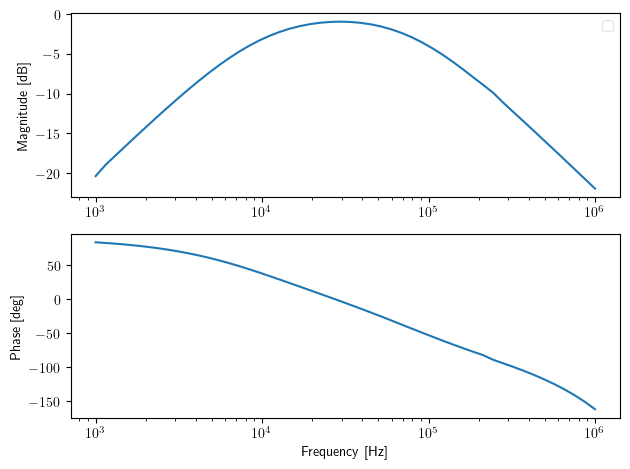

In [19]:
from pyrpl.hardware_modules.iir.iir_theory import bodeplot
%matplotlib inline
plt.clf()

bodeplot([(freqs, transfer_func, "")], xlog=True)